In [1]:
import numpy as np
import matplotlib.pyplot as plt
import lmdb
import pickle
import statistics


In [2]:
import numpy as np

# 读取 npz 文件中的数据
data = np.load('/home/zjy/code/mycode/ocp/results/2024-09-20-18-16-32/is2re_predictions.npz')

# 提取 ids1, ids2 和 energy
ids1 = data['ids1']
ids2 = data['ids2']
energy = data['energy']

# 将 ids1 和 ids2 转换为数值
ids1_numeric = ids1.astype(int)
ids2_numeric = ids2.astype(int)

# 将 ids1 和 ids2 合并为一个键，用于排序
combined_ids = list(zip(ids1_numeric, ids2_numeric))

# 创建一个索引列表，先根据 ids1_numeric 排序，然后再根据 ids2_numeric 排序
sorted_indices = np.lexsort((ids2_numeric, ids1_numeric))

# 根据排序后的索引获取排序后的 energy 列表
energy_list = [energy[i] for i in sorted_indices]

print(energy_list)
print(len(energy_list))


[-1.4125566, -1.6514285, -6.573028, -0.9457116, -2.5241323, -0.50609684, -2.023813, -2.1802135, -1.7908518, -1.9900877, -4.431841, -5.9360733, -5.512795, -2.6494963, -1.0021697, -1.4027405, -5.578424, -1.1189724, -5.2540264, -1.7856817, -1.6173173, -1.3991233, -1.7529438, -5.059417, -1.3044524, -1.4515176, -4.700489, -5.4539375, -2.9535983, -3.7443926, -5.5579076, -3.4529898, -2.5387585, -5.1338387, -1.2591372, -1.175114, -1.9139085, -3.2238832, -4.544641, -3.1703842, -4.7307515, -4.5662684, -0.92330444, -4.0043592, -1.2144141, -0.9553325, -5.3667336, -4.0551476, -3.2897022, -0.7683965, -0.63501966, -2.4000778, -1.223413, -1.1280997, -1.6777853, -5.626588, -1.2876686, -0.7731881, -5.296663, -4.514026, -4.0587277, -1.2170491, -1.4454411, -2.6627665, -5.854224, -0.61139923, -6.094787, -4.028801, -5.0470557, -1.5335187, -1.9890833, -4.558747, -1.2769706, -1.2665865, -0.9335753, -0.92328537, -1.1170425, -2.9307878, -4.920934, -1.1401991, -1.596034, -1.4183939, -1.4133221, -3.2441874, -4.02

In [4]:
import lmdb
import pickle
import numpy as np

# 打开 LMDB 文件
env = lmdb.open('/home/zjy/code/mycode/ocp/test_data/Cu_self/test_1', readonly=True)

# 列表用于存储 (sid, fid, y) 元组
data_list = []

# 从 LMDB 文件中读取数据并提取 sid, fid 和 y 值
with env.begin(write=False) as txn:
    cursor = txn.cursor()
    for key, value in cursor:
        info = pickle.loads(value)
        data_list.append((info.sid, info.fid, info.y))

# 关闭 LMDB 文件
env.close()

# 将数据转换为 numpy 数组以便于排序
data_array = np.array(data_list, dtype=[('sid', 'i4'), ('fid', 'i4'), ('y', 'f8')])

# 按照 sid 和 fid 对 data_array 进行排序
sorted_data_array = np.sort(data_array, order=['sid', 'fid'])

# 提取排序后的 sid、fid 和 y 值列表
sid_list = sorted_data_array['sid'].tolist()
fid_list = sorted_data_array['fid'].tolist()
test_list = sorted_data_array['y'].tolist()

# print("sid:", sid_list)
# print("fid:", fid_list)
print("y:", test_list)
print("Length:", len(test_list))


y: [-1.6787788299999988, -2.515096849999992, -7.122679519999963, -1.0906176700000003, -2.006113400000004, -0.05919419999997899, -1.9215921499999808, -2.6851568499999985, -1.897180899999995, -2.120336230000021, -4.710710039999981, -5.607886719999982, -5.643383909999898, -2.478358309999976, -0.44039744999997765, -0.998891599999979, -5.56713726000001, -1.2717280900000105, -5.141736040000012, -1.7106572799999924, -1.5533026900000095, -1.5508017299999892, -1.7103134099999693, -5.1312214099999665, -1.0641300099999569, -1.7103354500000023, -4.386653489999986, -5.829943790000016, -2.808966299999952, -3.70703967999998, -5.280103940000004, -3.0477606199999627, -2.546956730000005, -4.731953389999944, -1.299985399999997, -1.1344997699999624, -1.6055489199999613, -3.216923720000011, -4.692366399999969, -3.060369630000025, -4.3702397500000245, -4.842132180000021, -1.0054868299999953, -3.9898738800000046, -1.1804645199999868, -0.9542441899999687, -5.748607890000017, -3.701210259999982, -3.29872014000

In [5]:
efficient = [abs((t - e) / t)  for e, t in zip(energy_list, test_list)]

In [6]:
# efficient
statistics.median(efficient)

0.0731996819614974

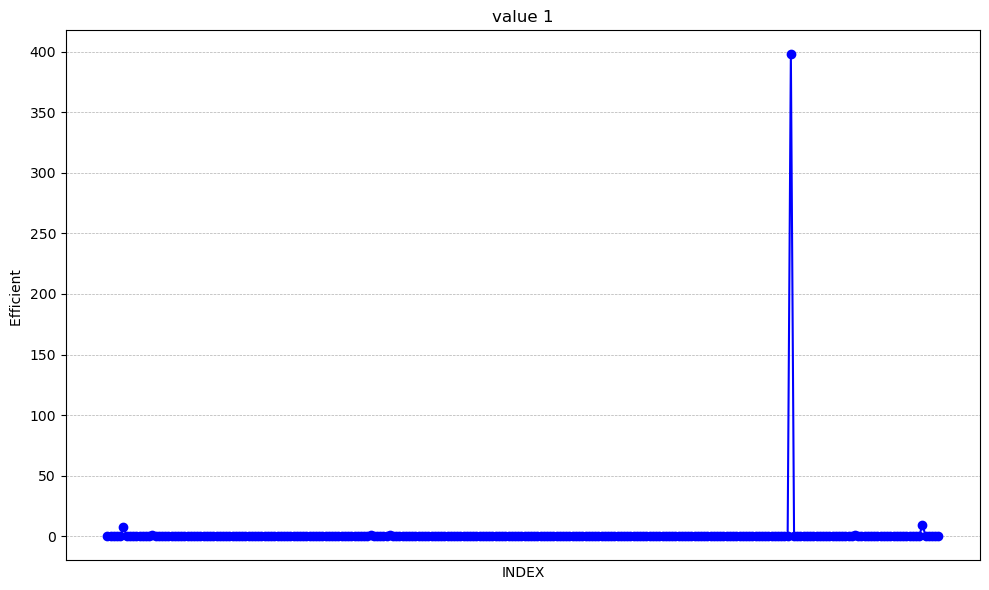

In [7]:
x = list(range(1, len(efficient) + 1))

plt.figure(figsize=(10, 6))  # 设置图像大小
plt.plot(x, efficient, marker='o', linestyle='-', color='b')  # 绘制折线图

plt.xlabel("INDEX")  # 设置横坐标标签
plt.ylabel("Efficient ")     # 设置纵坐标标签
plt.title("value 1")  # 设置图像标题


plt.xticks([])  # 设置横坐标刻度为正整数

plt.grid(True, which='both', linestyle='--', linewidth=0.5)  # 添加网格线
plt.tight_layout()  # 调整图像布局

plt.show()  # 显示图像

In [8]:
count_below_0_4 = sum(1 for value in efficient if value < 1)

# 计算比例
ratio = count_below_0_4 / len(efficient)
ratio

0.9730769230769231

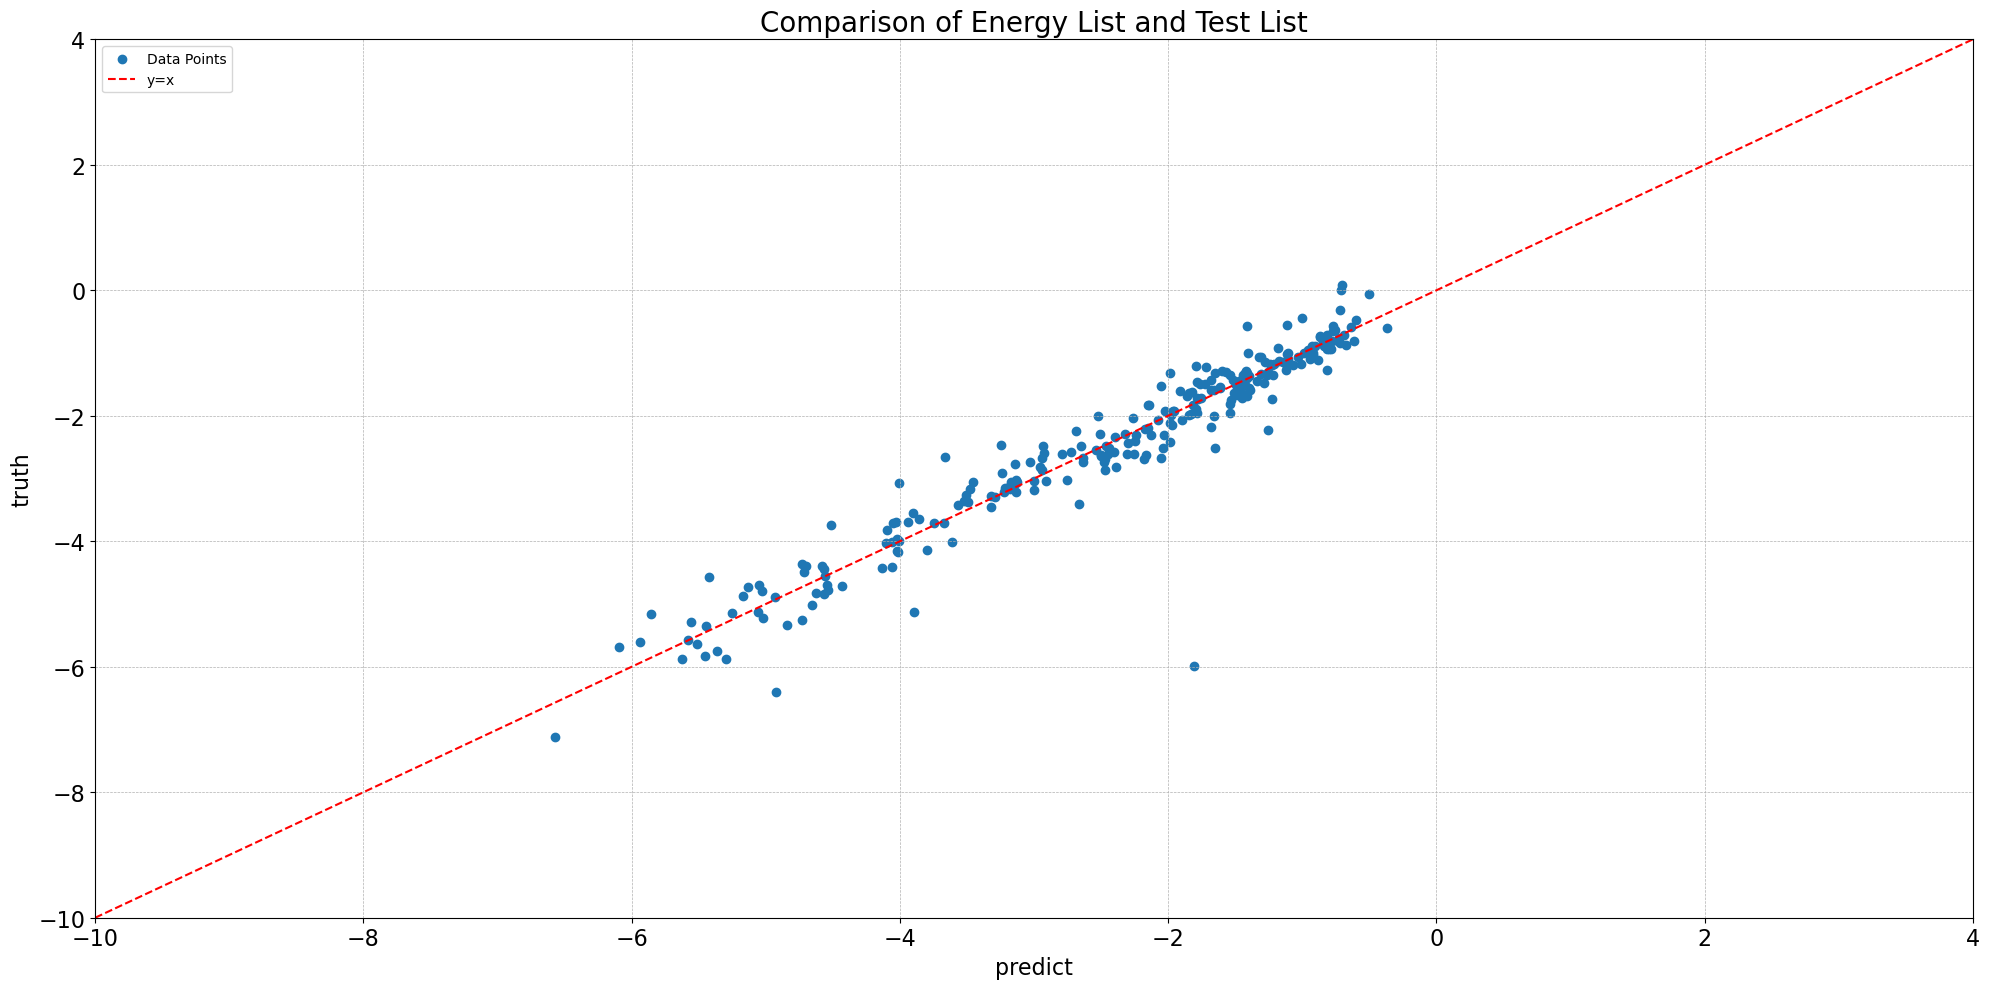

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# 创建横坐标和纵坐标
x = energy_list
y = test_list

plt.figure(figsize=(20, 10))  # 设置图像大小

# 绘制散点图以检查线性分布
plt.scatter(x, y, label='Data Points', marker='o')

# 添加 y=x 的虚线
# min_val = min(min(x), min(y))
# max_val = max(max(x), max(y))
min_val = -10
max_val = 4
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='r', label='y=x')

plt.xlim(-10, 4)
plt.ylim(-10, 4)
# 添加标题和图例
plt.title('Comparison of Energy List and Test List', fontsize=20)
plt.xlabel('predict', fontsize=16)
plt.ylabel('truth', fontsize=16)
plt.legend()

plt.tick_params(axis='x', labelsize=16)
plt.tick_params(axis='y', labelsize=16)

# 显示图形
plt.tight_layout()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()



In [10]:
difference = [abs(e - t) for e, t in zip(energy_list, test_list)]
filtered_difference = [d for d in difference if d <= 0.3]
len(filtered_difference)
# 输出结果
# print(difference)

189

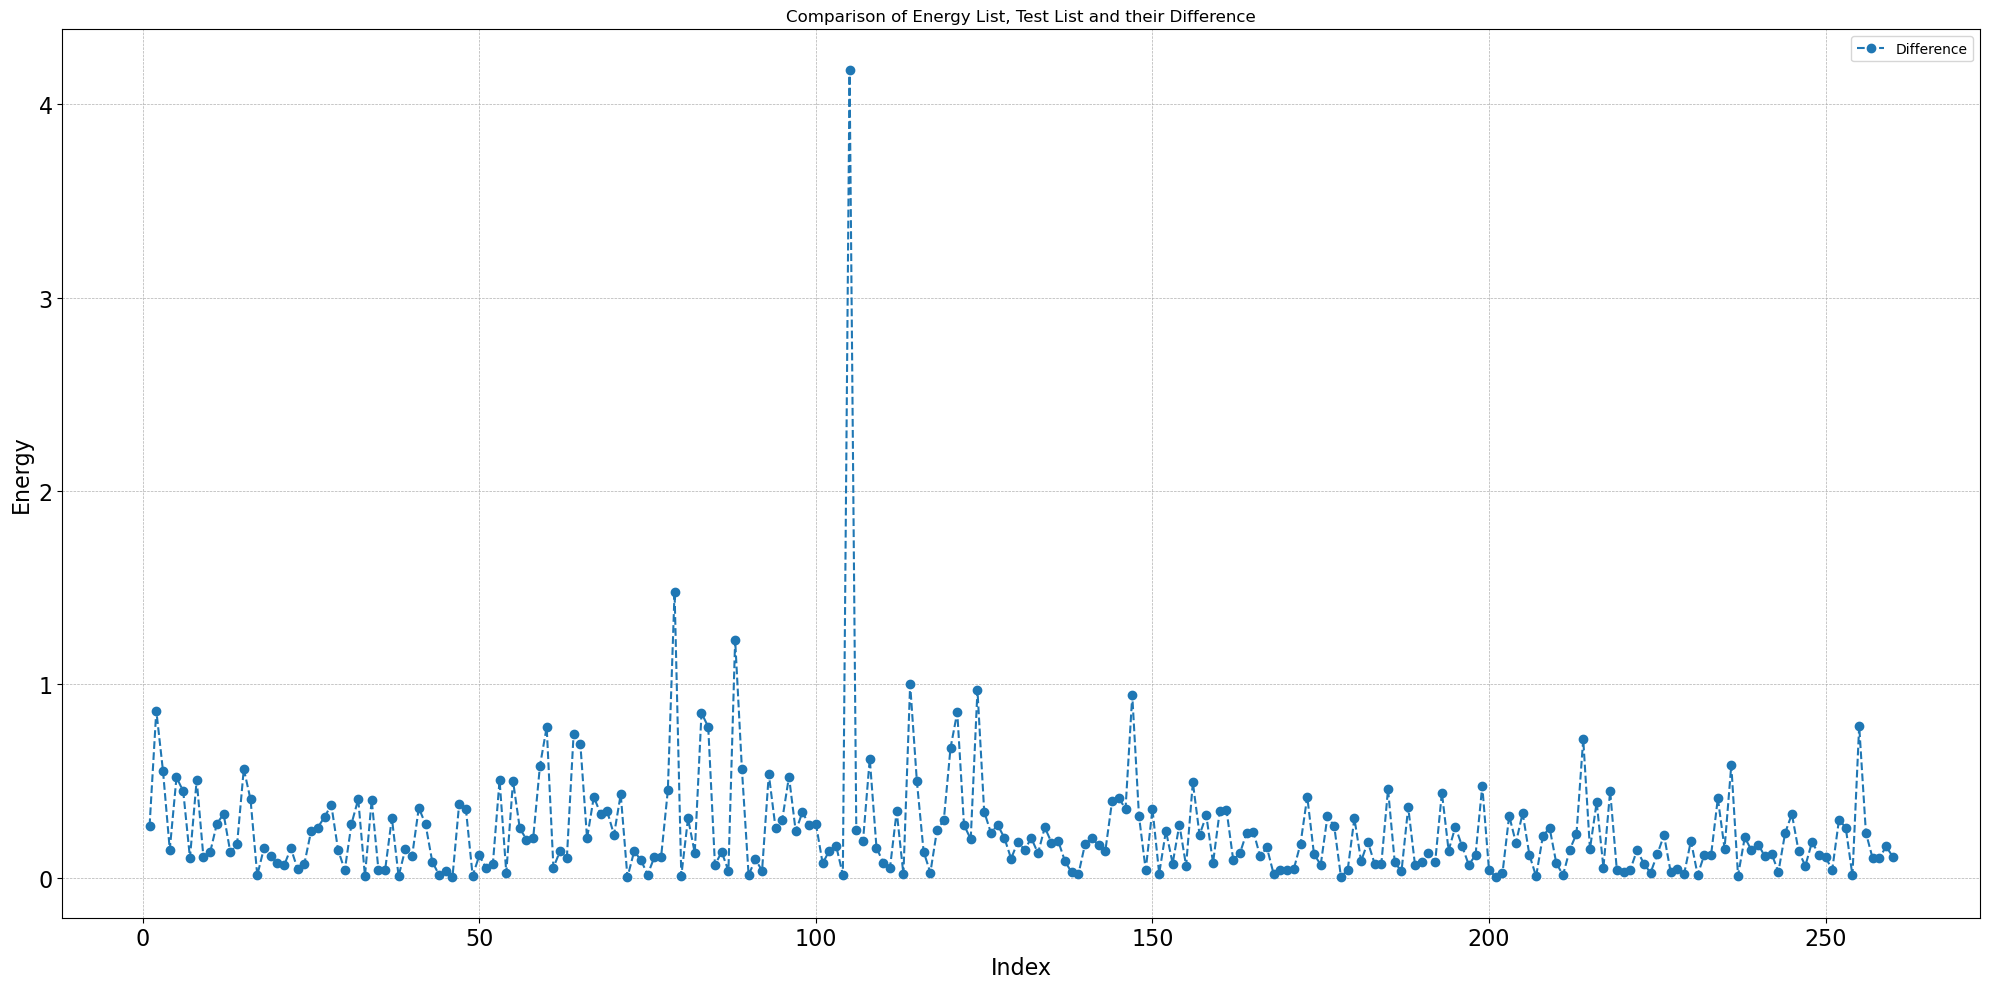

In [11]:
x = range(1, len(energy_list) + 1)
plt.figure(figsize=(20, 10))  # 设置图像大小
# 做差值
plt.plot(x, difference, label='Difference', marker='o', linestyle='--')
plt.title('Comparison of Energy List, Test List and their Difference')
plt.xlabel('Index', fontsize=16)
plt.ylabel('Energy', fontsize=16)
plt.legend()

plt.tick_params(axis='x', labelsize=16)
plt.tick_params(axis='y', labelsize=16)

# 显示图形
plt.tight_layout()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

In [12]:
# def mean_absolute_error(data_list):
#     # 计算平均绝对误差
#     mae = sum(data_list) / len(data_list)
#     return mae
# 
# # 示例
# print(mean_absolute_error(difference))

import numpy as np

def calculate_errors(data_list):
    # 计算平均绝对误差 (MAE)
    mae = np.mean(np.abs(data_list))
    
    # 计算均方误差 (MSE)
    mse = np.mean(np.square(data_list))
    
    # 计算均方根误差 (RMSE)
    rmse = np.sqrt(mse)
    
    return mae, mse, rmse

mae, mse, rmse = calculate_errors(difference)

print(f"MAE: {mae}") 
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

MAE: 0.2436761361112096
MSE: 0.16904469284630702
RMSE: 0.41115045037833414


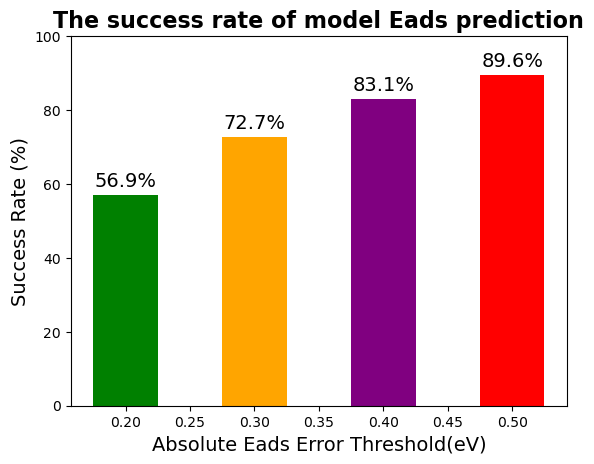

In [13]:
# n_difference = sum(1 for value in difference if value < 0.3)
# 
# # 计算比例
# ratio_diff = n_difference / len(difference)
# ratio_diff


# 定义不同的绝对误差阈值
thresholds = [0.2, 0.3, 0.4, 0.5]

# 计算每个阈值下的成功率
success_rates = [sum(1 for value in difference if value < threshold) / len(difference) for threshold in thresholds]

# 转换为百分比
success_rates_percentage = [rate * 100 for rate in success_rates]

# 定义柱子的颜色
colors = ['green', 'orange', 'purple','red']

# 创建条形图
fig, ax = plt.subplots()
bars = ax.bar(thresholds, success_rates_percentage, color=colors, width=0.05)

# 添加数据标签
for bar, rate in zip(bars, success_rates_percentage):
    height = bar.get_height()
    ax.annotate(f'{rate:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=14)

# 设置标题和标签
ax.set_title('The success rate of model Eads prediction', fontsize=16, fontweight='bold')
ax.set_xlabel('Absolute Eads Error Threshold(eV)', fontsize=14)
ax.set_ylabel('Success Rate (%)', fontsize=14)
ax.set_ylim(0, 100)

# 显示图形
plt.show()

In [150]:
import lmdb
import pickle
import numpy as np

# 读取 npz 文件中的数据
data = np.load('/home/zjy/code/mycode/ocp/data_analyse/2024-07-22-09-04-00/is2re_predictions.npz')

# 提取 ids1, ids2 和 energy
ids1 = data['ids1']
ids2 = data['ids2']
energy = data['energy']

# 将 ids1 和 ids2 转换为数值
ids1_numeric = ids1.astype(int)
ids2_numeric = ids2.astype(int)

# 将 ids1 和 ids2 合并为一个键，用于排序
combined_ids = list(zip(ids1_numeric, ids2_numeric))

# 创建一个索引列表，先根据 ids1_numeric 排序，然后再根据 ids2_numeric 排序
sorted_indices = np.lexsort((ids2_numeric, ids1_numeric))

# 根据排序后的索引获取排序后的 energy 列表
sorted_energy = energy[sorted_indices]

# 打开 LMDB 文件以读取数据
env = lmdb.open('/home/zjy/code/mycode/ocp/test_data/all_CNN/test/', readonly=True)

# 列表用于存储 (sid, fid, y) 元组
data_list = []

# 从 LMDB 文件中读取数据并提取 sid, fid 和 y 值
with env.begin(write=False) as txn:
    cursor = txn.cursor()
    for key, value in cursor:
        info = pickle.loads(value)
        sid = info.sid
        fid = info.fid
        y = info.y
        data_list.append((sid, fid, y, key, value))

# 将 data_list 转换为 numpy 数组
data_array = np.array(data_list, dtype=[('sid', 'i4'), ('fid', 'i4'), ('y', 'f8'), ('key', 'O'), ('value', 'O')])

# 按照 sid 和 fid 对 data_array 进行排序
sorted_data_array = np.sort(data_array, order=['sid', 'fid'])

# 提取排序后的 y 列表以及 key 和 value
sorted_y = sorted_data_array['y']
sorted_keys = sorted_data_array['key']
sorted_values = sorted_data_array['value']

# 筛选出符合条件的数据
filtered_data = []

for i in range(len(sorted_y)):
    energy = sorted_energy[i]  # 获取对应的 energy
    y = sorted_y[i]
    key = sorted_keys[i]
    value = sorted_values[i]
    
    # 判断 energy 和 y 的绝对差值是否小于 0.35
    if 0.5 < abs(y - energy) < 0.7:
        filtered_data.append((key, value))  # 保存符合条件的键值对

# 关闭 LMDB 文件
env.close()

# 打开一个新的 LMDB 文件以存储筛选后的数据
env_new = lmdb.open('/home/zjy/code/mycode/ocp/test_data/all_CNN/test/test_050_070', map_size=int(1e12))

with env_new.begin(write=True) as txn_new:
    for new_key, (old_key, value) in enumerate(filtered_data):
        new_key_bytes = str(new_key).encode('ascii')  # 将新键转换为字节类型
        txn_new.put(new_key_bytes, value)  # 使用新键存储

# 关闭新的 LMDB 文件
env_new.close()

print(f"Filtered {len(filtered_data)} entries and stored in the new LMDB file with sequential keys.")


Filtered 99 entries and stored in the new LMDB file with sequential keys.
